# KKBox Survival Analysis - Exploratory Analysis

In this notebook, we perform exploratory survival analysis on KKBox subscription data to understand:
- Overall customer retention patterns
- When customers are most likely to churn
- How different customer segments compare in survival
- Which factors significantly affect retention

## Methods

1. **Population-level survival** - Overall Kaplan-Meier curve
2. **Stratified analysis** - Compare survival across segments:
   - Initial payment plan duration
   - Initial payment method
   - Prior subscriptions (reactivations)
3. **Statistical testing** - Log-rank tests to confirm differences are real
4. **Business insights** - Interpret findings for actionable recommendations

## Prerequisites

You must have completed the **Data Preparation** notebook which created:
- `kkbox_subscriptions.pkl` - Clean subscription-level dataset
- `cleaned_transactions.pkl` - Clean transaction data

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines.utils import median_survival_times
from lifelines.statistics import pairwise_logrank_test, multivariate_logrank_test
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')


In [3]:
# Load subscription data from data prep notebook
subscriptions_pd = pd.read_csv('../notebooks/kkbox_subscriptions.csv')

print(f"  Unique users: {subscriptions_pd['msno'].nunique():,}")
print(f"  Date range: {subscriptions_pd['starts_at'].min()} to {subscriptions_pd['starts_at'].max()}")

# Display basic statistics
print("\nChurn distribution:")
print(subscriptions_pd['churned'].value_counts())

print("\nData preview:")
print(subscriptions_pd.head(10))
subscriptions_pd.shape

  Unique users: 2,420,599
  Date range: 2015-01-01 to 2017-03-31

Churn distribution:
churned
1    1904496
0    1227231
Name: count, dtype: int64

Data preview:
   subscription_id                                          msno   starts_at  \
0                1  +++FOrTS7ab3tIgIh8eWwX4FqRv8w/FoiOuyXsFvphY=  2016-09-09   
1                2  +++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s=  2015-11-21   
2                3  +++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=  2016-11-16   
3                4  +++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=  2015-01-31   
4                5  +++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=  2016-07-31   
5                6  +++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=  2015-01-26   
6                7  ++/9R3sX37CjxbY/AaGvbwr3QkwElKBCtSvVzhCBDOk=  2016-03-15   
7                8  ++/Gw1B9K+XOlB3hLTloeUK2QlCa2m+BJ8TrzGf7djI=  2015-01-13   
8                9  ++/TR7WI15q2ZCtOXmoap7jR+kEhbMVE5swOqsfqpqI=  2015-01-24   
9               10  ++/UDNo9DLrxT8QVGiD

(3131727, 7)

## Step 1 - Population-Level Survival Analysis

Objective:
Fit a Kaplan-Meier estimator to the entire subscription population to understand:
- Overall survival probability over time
- Median survival time (how long typical subscriptions last)
- When most churn occurs

What is Kaplan-Meier?

The Kaplan-Meier estimator calculates the probability of survival (remaining subscribed) at each time point, properly accounting for:
- **Events** - customers who churned
- **Censoring** - customers still active when observation ended
  
Unlike simple retention rates, KM properly handles censored observations, i.e, subscriptions that are still active at the end of observation.

In [4]:
# Initialize Kaplan-Meier Fitter
kmf = KaplanMeierFitter(alpha=0.05)  # 95% confidence interval

# Fit the model

kmf.fit(
    durations=subscriptions_pd['duration_days'],  # How long each subscription lasted
    event_observed=subscriptions_pd['churned'],   # Whether they churned (1) or censored (0)
    label='All Subscriptions'
)

print("Model fitted successfully")
print(f"\nObservations: {len(kmf.event_observed):,}")
print(f"  Events (churned): {int(kmf.event_observed.sum()):,}")
print(f"  Censored (still active): {int((~kmf.event_observed.astype(bool)).sum()):,}")
print(f"  Censored (still active): {int((kmf.event_observed == 0).sum()):,}")

Model fitted successfully

Observations: 3,131,727
  Events (churned): 1,904,496
  Censored (still active): 1,227,231
  Censored (still active): 1,227,231


### Calculate Median Survival Time

**Median survival time** = the point where 50% of subscriptions have ended (churned or censored)

This represents the typical subscription lifespan.

In [5]:
# Get median survival time
median_survival = kmf.median_survival_time_

if np.isinf(median_survival):
    print(f"\nMedian survival time: UNDEFINED (more than 50% of subscriptions are still active)")
    print(f"                      (Cannot calculate - survival curve never drops below 50%)")
else:
    print(f"\nMedian survival time: {median_survival:.0f} days")
    print(f"                      ({median_survival/30:.1f} months)")
    print(f"   50% of subscriptions end within {median_survival:.0f} days")


Median survival time: 184 days
                      (6.1 months)
   50% of subscriptions end within 184 days


### Survival Probabilities

Let's examine what percentage of customers "survive" past common subscription milestones.

In [6]:
# Key time points to examine
milestones = [30, 60, 90, 180, 365, 730]

print(f"{'Days':>6} {'Months':>8} {'Survival %':>12} {'Interpretation':>30}")

for days in milestones:
    # Find survival probability at this day
    available_days = kmf.survival_function_.index[kmf.survival_function_.index <= days]
    
    if len(available_days) > 0:
        closest_day = available_days.max()
        prob = kmf.survival_function_.loc[closest_day, 'All Subscriptions']
        months = days / 30
        
        # Interpretation
        if days == 30:
            interp = "After 1st renewal"
        elif days == 180:
            interp = "~Median survival"
        elif days == 365:
            interp = "1-year commitment"
        elif days == 730:
            interp = "2-year mark"
        else:
            interp = ""
        
        print(f"{days:6d} {months:8.1f} {prob*100:11.1f}% {interp:>30}")

# Calculate predictions using predict method
print("Exact probabilities:")
predictions = kmf.predict([30, 365, 730])
print(predictions)

  Days   Months   Survival %                 Interpretation
    30      1.0        77.9%              After 1st renewal
    60      2.0        65.6%                               
    90      3.0        60.7%                               
   180      6.0        50.5%               ~Median survival
   365     12.2        42.5%              1-year commitment
   730     24.3        29.9%                    2-year mark
Exact probabilities:
30    0.7790
365   0.4247
730   0.2990
Name: All Subscriptions, dtype: float64


### Visualize Overall Survival Curve

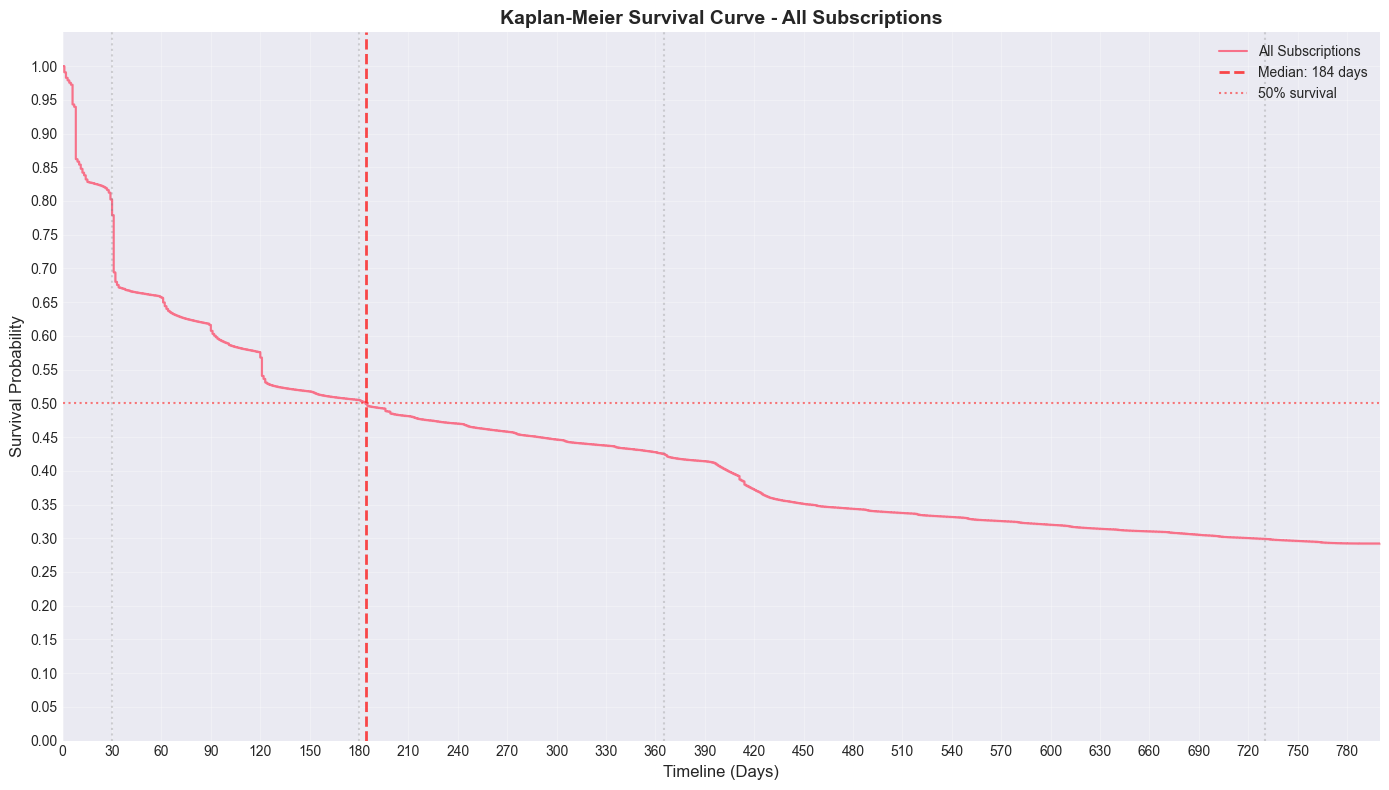

  Saved to: km_curve_overall.png


In [7]:
# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

# Plot the survival curve
kmf.plot_survival_function(ax=ax, ci_show=True)

# Customize plot
ax.set_xlabel('Timeline (Days)', fontsize=12)
ax.set_ylabel('Survival Probability', fontsize=12)
ax.set_title('Kaplan-Meier Survival Curve - All Subscriptions', 
             fontsize=14, fontweight='bold')
ax.set_xlim([0, 800])
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)

# Add median survival line
ax.axvline(x=median_survival, color='red', linestyle='--', 
           linewidth=2, alpha=0.7, label=f'Median: {median_survival:.0f} days')

# Add 50% survival line
ax.axhline(y=0.5, color='red', linestyle=':', 
           linewidth=1.5, alpha=0.5, label='50% survival')

# Add reference lines for key milestones
for days in [30, 180, 365, 730]:
    ax.axvline(x=days, color='gray', linestyle=':', alpha=0.3)
    
# Add x-axis ticks every 30 days
ax.set_xticks(range(0, 800, 30))

# Add y-axis ticks every 5%
ax.set_yticks(np.arange(0.0, 1.05, 0.05))

ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('km_curve_overall.png', dpi=300, bbox_inches='tight')
plt.show()

print("  Saved to: km_curve_overall.png")

## Step 2: Enrich Subscriptions with Attributes

To understand which factors affect survival, we need to enrich our subscription data with attributes from the initial transaction:
- Initial payment method
- Initial payment plan duration
- Registration channel (if available)

**Why Initial Transaction?**

We focus on attributes known at acquisition because:
- These are actionable (we can influence them during signup)
- They represent the customer's initial commitment level
- They're available before any churn occurs (predictive value)

**Method**

1. Load original transactions
2. Match subscriptions to their first transaction (starts_at = transaction_date)
3. Extract payment method and plan days from that transaction
4. Optionally add demographic data from members file

In [8]:
# Load original transaction data

transactions = pd.read_pickle('../notebooks/transactions_combined.pkl')  # From data prep notebook

print(f"Loaded {len(transactions):,} transactions")
print(f"Date range: {transactions['transaction_date'].min()} to {transactions['transaction_date'].max()}")

Loaded 22,949,831 transactions
Date range: 2015-01-01 00:00:00 to 2017-03-31 00:00:00


In [9]:
# Filter to valid transactions
transactions_valid = transactions[transactions['payment_plan_days'] > 0].copy()

# For each transaction date, get payment method and plan days
transaction_attributes = transactions_valid.groupby(['msno', 'transaction_date']).agg({
    'payment_method_id': 'first',  # Take first payment method on that date
    'payment_plan_days': 'first'   # Take first payment plan on that date
}).reset_index()

transaction_attributes.columns = ['msno', 'trans_at', 'payment_method_id', 'payment_plan_days']

print(f" Created {len(transaction_attributes):,} transaction-date records")
print("\nSample:")
print(transaction_attributes.head())

 Created 21,786,041 transaction-date records

Sample:
                                           msno   trans_at  payment_method_id  \
0  +++FOrTS7ab3tIgIh8eWwX4FqRv8w/FoiOuyXsFvphY= 2016-09-09                 35   
1  +++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s= 2015-11-21                 38   
2  +++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s= 2016-10-23                 22   
3  +++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o= 2016-11-16                 41   
4  +++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o= 2016-12-15                 41   

   payment_plan_days  
0                  7  
1                410  
2                395  
3                 30  
4                 30  


In [10]:
# Convert both date columns to the same format
subscriptions_pd['starts_at'] = pd.to_datetime(subscriptions_pd['starts_at']).dt.date
transaction_attributes['trans_at'] = pd.to_datetime(transaction_attributes['trans_at']).dt.date

# Merge subscriptions with transaction attributes
subscriptions_enriched = subscriptions_pd.merge(
    transaction_attributes,
    left_on=['msno', 'starts_at'],
    right_on=['msno', 'trans_at'],
    how='inner'
)

# Rename for clarity
subscriptions_enriched.rename(columns={
    'payment_method_id': 'init_payment_method_id',
    'payment_plan_days': 'init_payment_plan_days'
}, inplace=True)

# Drop redundant column
subscriptions_enriched.drop('trans_at', axis=1, inplace=True)

print(f"Matched {len(subscriptions_enriched):,} subscriptions")
print(f"({len(subscriptions_enriched)/len(subscriptions_pd)*100:.1f}% of original subscriptions)")

print("\n   Enriched data preview:")
print(subscriptions_enriched[['subscription_id', 'starts_at', 'ends_at', 'duration_days',
                               'churned', 'init_payment_method_id', 'init_payment_plan_days']].head())

Matched 3,131,727 subscriptions
(100.0% of original subscriptions)

   Enriched data preview:
   subscription_id   starts_at     ends_at  duration_days  churned  \
0                1  2016-09-09  2016-09-14              6        1   
1                2  2015-11-21         NaN            498        0   
2                3  2016-11-16         NaN            137        0   
3                4  2015-01-31  2016-03-19            414        1   
4                5  2016-07-31         NaN            245        0   

   init_payment_method_id  init_payment_plan_days  
0                      35                       7  
1                      38                     410  
2                      41                      30  
3                      39                      31  
4                      39                      30  


## Step 3: Stratified Survival Analysis - By Initial Payment Plan

Here, we compare survival curves across different initial payment plan durations to understand:
- Do longer initial commitments lead to better retention?
- When do different plan types experience churn?
- Should we incentivize longer-term plans?

**Method**

1. Categorise payment plans into meaningful groups
2. Filter to popular plans (enough data for statistical power)
3. Plot separate survival curves for each plan type
4. Test if differences are statistically significant

In [11]:
# Count subscriptions by payment plan days
plan_counts = subscriptions_enriched.groupby('init_payment_plan_days').agg({
    'msno': 'nunique',
    'subscription_id': 'count'
}).reset_index()

plan_counts.columns = ['Plan Days', 'Unique Customers', 'Total Subscriptions']
plan_counts = plan_counts.sort_values('Unique Customers', ascending=False)

print("\nTop 15 payment plans by customer count:")
print(plan_counts.head(15).to_string(index=False))

# Calculate percentages
total_customers = plan_counts['Unique Customers'].sum()
plan_counts['% of Customers'] = (plan_counts['Unique Customers'] / total_customers * 100).round(1)

print("\nTop 5 plans with percentages:")
print(plan_counts.head(5)[['Plan Days', 'Unique Customers', '% of Customers']].to_string(index=False))


Top 15 payment plans by customer count:
 Plan Days  Unique Customers  Total Subscriptions
        30           1723803              2154215
         7            478626               497965
        31            226573               227094
       410             83422                85456
       195             55245                58633
       180             23195                25645
        10             15596                16224
        90             12887                12954
       100             12448                13339
       395              9173                 9176
        14              5378                 5386
       200              3923                 4015
       360              3759                 3784
        60              3603                 3763
       120              3099                 3099

Top 5 plans with percentages:
 Plan Days  Unique Customers  % of Customers
        30           1723803         64.5000
         7            478626         1

In [12]:
# Filter to plans with sufficient data for analysis
popular_plans = plan_counts[
    plan_counts['Unique Customers'] > 10000
]['Plan Days'].tolist()

print(f"\nPlans with >10,000 customers: {len(popular_plans)}")
print(f"Plans included: {sorted(popular_plans)}")

# Filter dataset
payment_plan_days_pd = subscriptions_enriched[
    subscriptions_enriched['init_payment_plan_days'].isin(popular_plans)
].copy()

print(f"\nFiltered dataset:")
print(f"  Subscriptions: {len(payment_plan_days_pd):,}")
print(f"  Percentage of total: {len(payment_plan_days_pd)/len(subscriptions_enriched)*100:.1f}%")


Plans with >10,000 customers: 9
Plans included: [7, 10, 30, 31, 90, 100, 180, 195, 410]

Filtered dataset:
  Subscriptions: 3,091,525
  Percentage of total: 98.7%


Why filter?"
Plans with few customers lead to:
- Wide confidence intervals (unreliable)
- Weak statistical tests
- Cluttered visualizations"

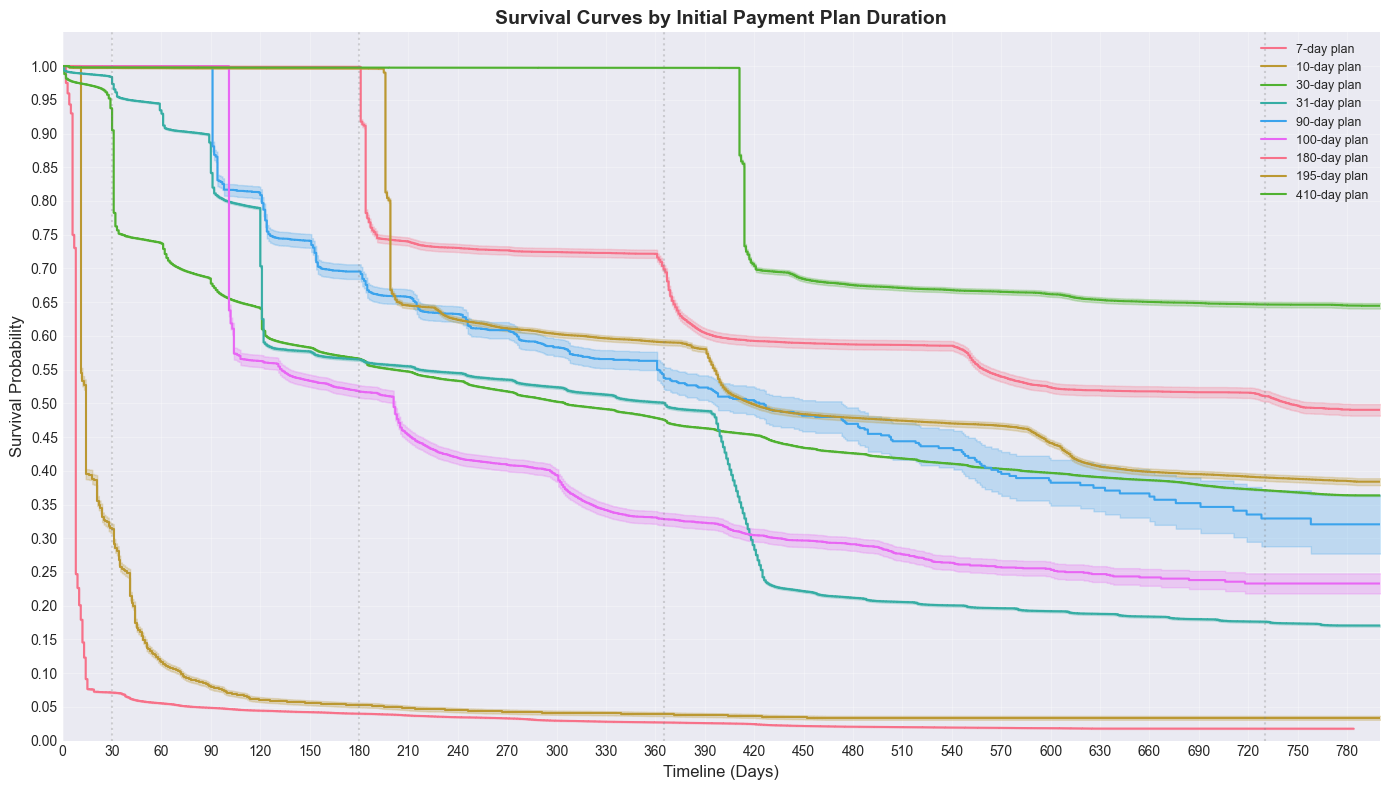

  Saved to: km_curves_by_payment_plan.png


In [13]:
# Plot survival curves by payment plan
fig, ax = plt.subplots(figsize=(14, 8))

# Store results for comparison
plan_results = []

# Fit and plot separate curve for each payment plan
for plan_days, plan_data in payment_plan_days_pd.groupby('init_payment_plan_days'):
    # Fit KM model
    kmf_plan = KaplanMeierFitter(alpha=0.05)
    kmf_plan.fit(
        durations=plan_data['duration_days'],
        event_observed=plan_data['churned'],
        label=f'{int(plan_days)}-day plan'
    )
    
    # Plot
    kmf_plan.plot_survival_function(ax=ax, ci_show=True)  # Show confidence intervals
    
    # Store median for comparison
    plan_results.append({
        'Plan Days': int(plan_days),
        'N Subscriptions': len(plan_data),
        'Churned': int(plan_data['churned'].sum()),
        'Censored': int((1 - plan_data['churned']).sum()),
        'Median Survival (days)': kmf_plan.median_survival_time_,
        'Median Survival (months)': kmf_plan.median_survival_time_ / 30
    })

# Customize plot
ax.set_xlabel('Timeline (Days)', fontsize=12)
ax.set_ylabel('Survival Probability', fontsize=12)
ax.set_title('Survival Curves by Initial Payment Plan Duration', 
             fontsize=14, fontweight='bold')
ax.set_xlim([0, 800])
ax.set_ylim([0, 1.05])
ax.set_xticks(range(0, 800, 30))
ax.set_yticks(np.arange(0.0, 1.05, 0.05))
ax.grid(True, alpha=0.3)

# Add reference lines
for days in [30, 180, 365, 730]:
    ax.axvline(x=days, color='gray', alpha=0.3, linestyle=':')

ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('km_curves_by_payment_plan.png', dpi=300, bbox_inches='tight')
plt.show()

print("  Saved to: km_curves_by_payment_plan.png")

In [14]:
# Print comparison table
comparison_df = pd.DataFrame(plan_results).sort_values('Median Survival (days)', ascending=False)

print("\nRanked by median survival time (best to worst):")
print(comparison_df.to_string(index=False))

# Identify best and worst
best = comparison_df.iloc[0]
worst = comparison_df.iloc[-1]

print(f"\nBest performing plan: {best['Plan Days']}-day")
print(f"   Median survival: {best['Median Survival (days)']:.0f} days ({best['Median Survival (months)']:.1f} months)")

print(f"\nWorst performing plan: {worst['Plan Days']}-day")
print(f"   Median survival: {worst['Median Survival (days)']:.0f} days ({worst['Median Survival (months)']:.1f} months)")

print(f"\nDifference: {best['Median Survival (days)'] - worst['Median Survival (days)']:.0f} days")
print(f"   Best plan survives {(best['Median Survival (days)'] / worst['Median Survival (days)']):.1f}x longer!")


Ranked by median survival time (best to worst):
 Plan Days  N Subscriptions  Churned  Censored  Median Survival (days)  Median Survival (months)
       410            85456    20843     64613                     inf                       inf
       180            25645     8945     16700                745.0000                   24.8333
        90            12954     2872     10082                423.0000                   14.1000
       195            58633    28221     30412                418.0000                   13.9333
        31           227094   188326     38768                366.0000                   12.2000
        30          2154215  1136226   1017989                305.0000                   10.1667
       100            13339     7571      5768                201.0000                    6.7000
        10            16224    15568       656                 14.0000                    0.4667
         7           497965   480859     17106                  8.0000        

### Statistical Testing: Log-Rank Test

Purpose: Test whether the survival curves actually differ, or if the observed differences could be due to random chance.

Null Hypothesis (H₀): All payment plans have the same survival curve

Alternative Hypothesis (H₁): At least one plan has a different survival curve

**Decision rule:**
- If p-value < 0.05: Reject H₀ → Curves are significantly different 
- If p-value ≥ 0.05: Cannot reject H₀ → Not enough evidence of difference

In [15]:
# Perform pairwise log-rank test
log_rank_plans = pairwise_logrank_test(
    event_durations=payment_plan_days_pd['duration_days'],  # Changed from 'durations'
    groups=payment_plan_days_pd['init_payment_plan_days'],
    event_observed=payment_plan_days_pd['churned']
)

summary_plans = log_rank_plans.summary

print("\nPairwise log-rank test results:")
print(f"  Total comparisons: {len(summary_plans)}")
print(f"  (Comparing all pairs of payment plans)")

# How many are significant?
significant = summary_plans[summary_plans['p'] < 0.05]
not_significant = summary_plans[summary_plans['p'] >= 0.05]

print(f"\nSignificantly different (p < 0.05): {len(significant)}")
print(f"  Not significantly different (p ≥ 0.05): {len(not_significant)}")

if len(not_significant) > 0:
    print("\nPlan pairs that are NOT significantly different (p ≥ 0.05):")
    print(not_significant[['test_statistic', 'p']].to_string())
else:
    print("\nALL payment plan pairs have significantly different survival!")

# Show a few example comparisons
print("\nExample pairwise comparisons (first 5):")
print(summary_plans.head(5).to_string())


Pairwise log-rank test results:
  Total comparisons: 36
  (Comparing all pairs of payment plans)

Significantly different (p < 0.05): 36
  Not significantly different (p ≥ 0.05): 0

ALL payment plan pairs have significantly different survival!

Example pairwise comparisons (first 5):
       test_statistic      p  -log2(p)
7 10        9289.8905 0.0000       inf
  30     2071881.0036 0.0000       inf
  31      434254.7114 0.0000       inf
  90       36215.7584 0.0000       inf
  100      30999.7190 0.0000       inf


## Step 4: Stratified Analysis - By Initial Payment Method

Compare survival across different payment methods to understand:
- Do certain payment methods correlate with better retention?
- Are there payment reliability differences (credit cards vs prepaid)?
- Should we incentivize specific payment methods?

**Note:** Without business knowledge of what each payment method ID represents, we can identify patterns but will need KKBox domain expertise to fully interpret them.

In [16]:
# Count by payment method
method_counts = subscriptions_enriched.groupby('init_payment_method_id').agg({
    'msno': 'nunique',
    'subscription_id': 'count'
}).reset_index()

method_counts.columns = ['Payment Method', 'Unique Customers', 'Total Subscriptions']
method_counts = method_counts.sort_values('Unique Customers', ascending=False)

print("\nTop 15 payment methods:")
print(method_counts.head(15).to_string(index=False))

# Filter to methods with > 10,000 customers
popular_methods = method_counts[
    method_counts['Unique Customers'] > 10000
]['Payment Method'].tolist()

print(f"\nPayment methods with >10,000 customers: {len(popular_methods)}")
print(f"Methods: {sorted([int(m) for m in popular_methods])}")

payment_methods_pd = subscriptions_enriched[
    subscriptions_enriched['init_payment_method_id'].isin(popular_methods)
].copy()

print(f"\nFiltered to {len(payment_methods_pd):,} subscriptions")
print(f"({len(payment_methods_pd)/len(subscriptions_enriched)*100:.1f}% of total)")


Top 15 payment methods:
 Payment Method  Unique Customers  Total Subscriptions
             41           1007334              1167638
             35            460859               477097
             38            351004               490693
             40            136756               207011
             36            119221               145236
             39            106168               180992
             32            104722               110260
             37             55741                83882
             34             39009                39696
             29             33861                36508
             30             33058                35195
             33             27413                29453
             28             19989                29931
             22             15769                16101
             20             15216                16385

Payment methods with >10,000 customers: 16
Methods: [20, 22, 28, 29, 30, 31, 32, 33, 34, 35, 3

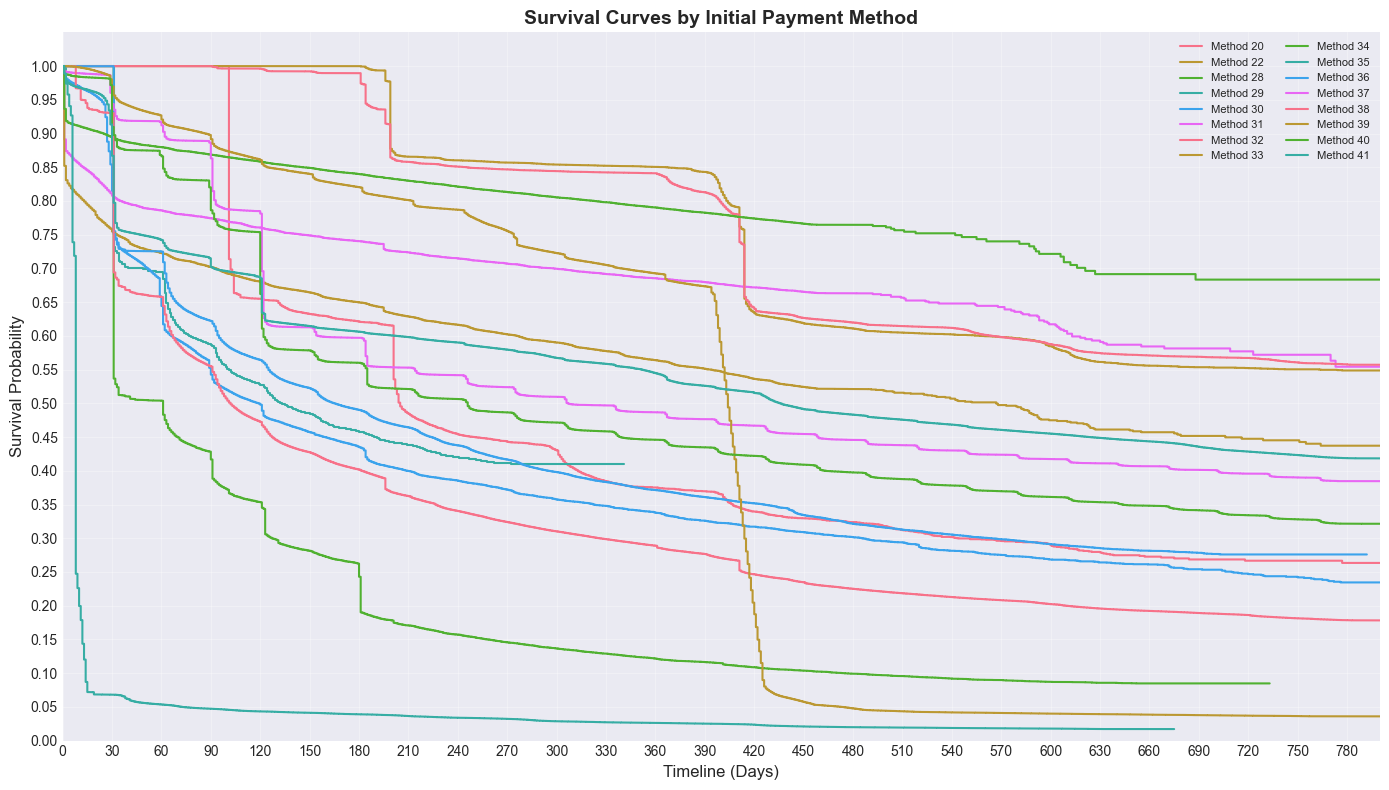


Median survival by payment method (ranked):
 Payment Method       N  Median Survival
             22   16101              inf
             31   16299              inf
             32  110260              inf
             34   39696              inf
             33   29453         567.0000
             41 1167638         436.0000
             39  180992         404.0000
             37   83882         307.0000
             40  207011         246.0000
             20   16385         205.0000
             36  145236         165.0000
             29   36508         133.0000
             30   35195         119.0000
             38  490693         102.0000
             28   29931          61.0000
             35  477097           8.0000


In [17]:
# Plot survival curves by payment method

fig, ax = plt.subplots(figsize=(14, 8))

method_results = []

for method, data in payment_methods_pd.groupby('init_payment_method_id'):
    kmf_method = KaplanMeierFitter(alpha=0.05)
    kmf_method.fit(
        durations=data['duration_days'],
        event_observed=data['churned'],
        label=f'Method {int(method)}'
    )
    
    kmf_method.plot_survival_function(ax=ax, ci_show=False)  # Hide CI to reduce clutter
    
    method_results.append({
        'Payment Method': int(method),
        'N': len(data),
        'Median Survival': kmf_method.median_survival_time_
    })

ax.set_xlabel('Timeline (Days)', fontsize=12)
ax.set_ylabel('Survival Probability', fontsize=12)
ax.set_title('Survival Curves by Initial Payment Method', fontsize=14, fontweight='bold')
ax.set_xlim([0, 800])
ax.set_ylim([0, 1.05])
ax.set_xticks(range(0, 800, 30))
ax.set_yticks(np.arange(0.0, 1.05, 0.05))
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('km_curves_by_payment_method.png', dpi=300)
plt.show()

# Print comparison
comparison = pd.DataFrame(method_results).sort_values('Median Survival', ascending=False)
print("\nMedian survival by payment method (ranked):")
print(comparison.to_string(index=False))

In [18]:
# Perform pairwise log-rank test
log_rank_plans = pairwise_logrank_test(
    event_durations=payment_plan_days_pd['duration_days'],
    event_observed=payment_plan_days_pd['churned'],
    groups=payment_plan_days_pd['init_payment_plan_days']
)

summary_plans = log_rank_plans.summary

print("\nPairwise log-rank test results:")
print(f"  Total comparisons: {len(summary_plans)}")

# How many are significant?
significant = summary_plans[summary_plans['p'] < 0.05]
not_significant = summary_plans[summary_plans['p'] >= 0.05]

print(f"\nSignificantly different (p < 0.05): {len(significant)}")
print(f"Not significantly different (p ≥ 0.05): {len(not_significant)}")

if len(not_significant) > 0:
    print("\nPlan pairs that are NOT significantly different (p ≥ 0.05):")
    valid_nonsig = not_significant[not_significant['p'].notna()]
    if len(valid_nonsig) > 0:
        print(valid_nonsig[['test_statistic', 'p']].head(10).to_string())
else:
    print("\nALL payment plan pairs have significantly different survival!")

# Show a few example comparisons
print("\nExample pairwise comparisons (first 5):")
print(summary_plans.head(5).to_string())


Pairwise log-rank test results:
  Total comparisons: 36

Significantly different (p < 0.05): 36
Not significantly different (p ≥ 0.05): 0

ALL payment plan pairs have significantly different survival!

Example pairwise comparisons (first 5):
       test_statistic      p  -log2(p)
7 10        9289.8905 0.0000       inf
  30     2071881.0036 0.0000       inf
  31      434254.7114 0.0000       inf
  90       36215.7584 0.0000       inf
  100      30999.7190 0.0000       inf


## Step 5: Stratified Analysis - By Prior Subscriptions

Compare "boomerang customers" (those who churned and returned) vs first-time subscribers:
- Do returners have better or worse retention?
- Does retention improve with each reactivation?
- Should we have special win-back campaigns?

**The `prior_subscriptions` Variable**

- `0` = First subscription (never churned before)
- `1` = Second subscription (churned once, came back)
- `2` = Third subscription (churned twice, came back)
- etc.

**Hypothesis:** Customers who've churned and returned might:
- **Option A:** Be more loyal (they know they like the service)
- **Option B:** Be chronic churners (habit of leaving)

Let's find out!

In [19]:
# Distribution of prior subscriptions
prior_counts = subscriptions_pd.groupby('prior_subscriptions').agg({
    'subscription_id': 'count',
    'msno': 'nunique'
}).reset_index()

prior_counts.columns = ['Prior Subscriptions', 'Total Subscriptions', 'Unique Users']

print("\nSubscription counts by prior subscription count:")
print(prior_counts.head(10).to_string(index=False))

# Calculate percentages
total = prior_counts['Total Subscriptions'].sum()
prior_counts['% of Total'] = (prior_counts['Total Subscriptions'] / total * 100).round(1)

print("\nWith percentages:")
print(prior_counts.head(10)[['Prior Subscriptions', 'Total Subscriptions', '% of Total']].to_string(index=False))


Subscription counts by prior subscription count:
 Prior Subscriptions  Total Subscriptions  Unique Users
                   0              2420599       2420599
                   1               540731        540731
                   2               118281        118281
                   3                36963         36963
                   4                12568         12568
                   5                 2145          2145
                   6                  384           384
                   7                   53            53
                   8                    3             3

With percentages:
 Prior Subscriptions  Total Subscriptions  % of Total
                   0              2420599     77.3000
                   1               540731     17.3000
                   2               118281      3.8000
                   3                36963      1.2000
                   4                12568      0.4000
                   5                 2145      

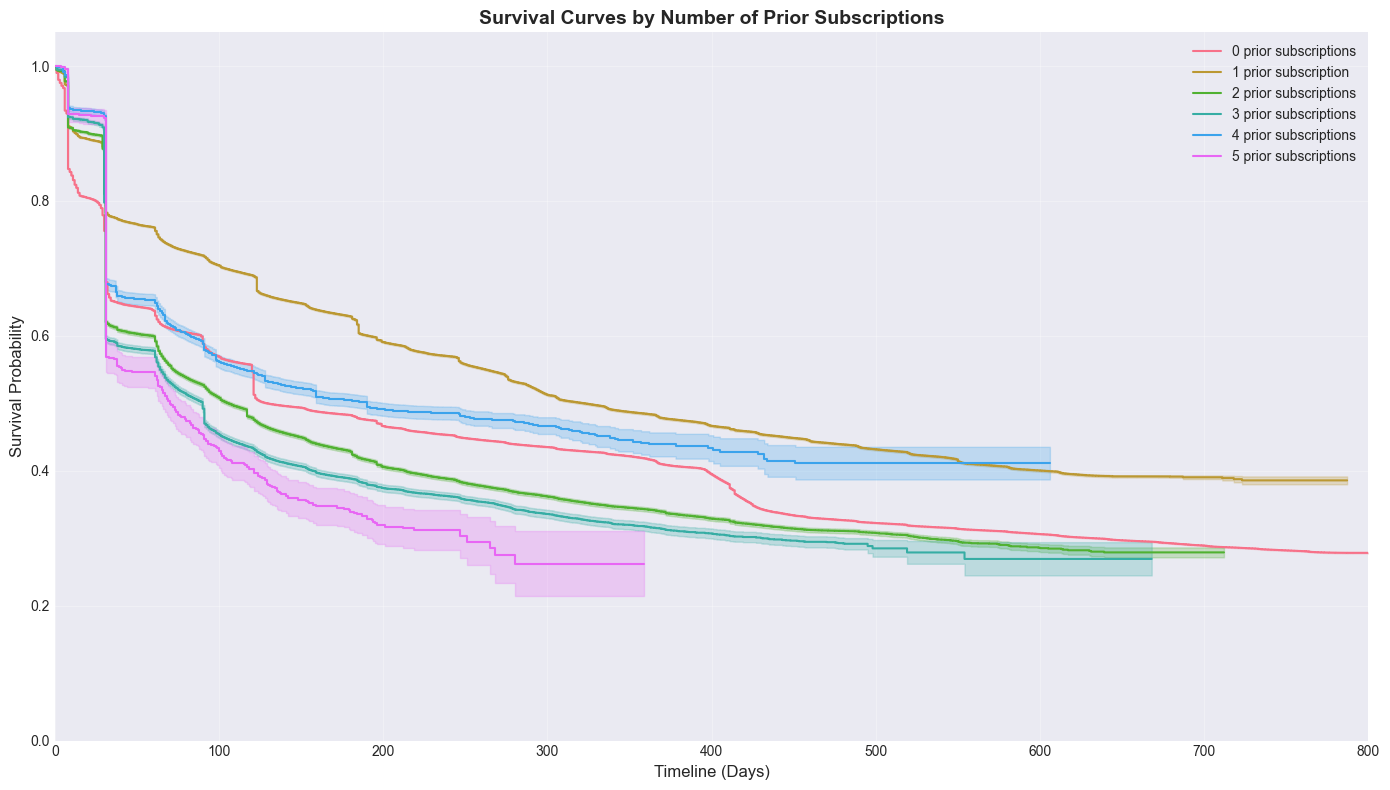


Median survival by prior subscriptions:
 Prior Subs       N  Median Survival
          1  540731         322.0000
          4   12568         190.0000
          0 2420599         129.0000
          2  118281         106.0000
          3   36963          90.0000
          5    2145          70.0000


In [21]:
# Plotting survival curves by prior subscription count
fig, ax = plt.subplots(figsize=(14, 8))

prior_results = []

# Only plot groups with enough data (>1000 subscriptions)
for prior, data in subscriptions_pd.groupby('prior_subscriptions'):
    if len(data) > 1000:  # Minimum threshold
        kmf_prior = KaplanMeierFitter(alpha=0.05)
        kmf_prior.fit(
            durations=data['duration_days'],
            event_observed=data['churned'],
            label=f'{int(prior)} prior subscription{"s" if prior != 1 else ""}'
        )
        
        kmf_prior.plot_survival_function(ax=ax, ci_show=True)
        
        prior_results.append({
            'Prior Subs': int(prior),
            'N': len(data),
            'Median Survival': kmf_prior.median_survival_time_
        })

ax.set_xlabel('Timeline (Days)', fontsize=12)
ax.set_ylabel('Survival Probability', fontsize=12)
ax.set_title('Survival Curves by Number of Prior Subscriptions', 
             fontsize=14, fontweight='bold')
ax.set_xlim([0, 800])
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('km_curves_by_prior_subs.png', dpi=300)
plt.show()

# Print comparison
comparison = pd.DataFrame(prior_results).sort_values('Median Survival', ascending=False)
print("\nMedian survival by prior subscriptions:")
print(comparison.to_string(index=False))

In [22]:
# Statistical testing
log_rank_prior = pairwise_logrank_test(
    event_durations=subscriptions_pd['duration_days'],
    event_observed=subscriptions_pd['churned'],
    groups=subscriptions_pd['prior_subscriptions']
)

summary_prior = log_rank_prior.summary
not_sig_prior = summary_prior[summary_prior['p'] >= 0.05]

print(f"\nTotal comparisons: {len(summary_prior)}")
print(f"Significantly different (p < 0.05): {len(summary_prior) - len(not_sig_prior)}")
print(f"NOT significantly different (p ≥ 0.05): {len(not_sig_prior)}")

if len(not_sig_prior) > 10:
    print("\nMany pairs are NOT significantly different")
    print("   Sample of non-significant pairs:")
    valid_nonsig = not_sig_prior[not_sig_prior['p'].notna()]
    if len(valid_nonsig) > 0:
        print(valid_nonsig[['test_statistic', 'p']].head(10).to_string())
else:
    print("\n→ Most groups have significantly different survival")


Total comparisons: 36
Significantly different (p < 0.05): 17
NOT significantly different (p ≥ 0.05): 19

Many pairs are NOT significantly different
   Sample of non-significant pairs:
     test_statistic      p
0 6          0.9704 0.3246
  7          1.4987 0.2209
  8          1.3295 0.2489
1 7          0.4956 0.4815
  8          0.7949 0.3726
2 6          3.6200 0.0571
  7          2.2069 0.1374
  8          1.5964 0.2064
3 5          0.5699 0.4503
  7          3.1977 0.0737
